# 04 邊緣偵測

這個 notebook 使用真實影像範例與工程導向觀察來記錄 edge detection 的學習內容。

重點是把三件事情連起來：

1. 每個 detector 背後的數學概念，
2. detector 實際產生的視覺結果，
3. 這個結果適合放到哪一種後續處理流程。

核心問題是：

> 每個 edge detector 到底在量測哪一種局部變化？  
> 這個量測結果是否真的有助於下一步處理？


In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import data, filters, img_as_float

OUTPUT_DIR = Path("outputs/04_edge_detection")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def normalize01(x):
    x = x.astype(np.float32)
    mn, mx = float(x.min()), float(x.max())
    if mx - mn < 1e-8:
        return np.zeros_like(x, dtype=np.float32)
    return (x - mn) / (mx - mn)

def to_u8(x):
    return (normalize01(x) * 255).astype(np.uint8)

def show_images(images, titles, figsize=(16, 5), cmaps=None, save_path=None):
    cmaps = cmaps or ["gray"] * len(images)
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), 1):
        plt.subplot(1, len(images), i)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmaps[i-1])
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

def crop(img, y1, y2, x1, x2):
    return img[y1:y2, x1:x2]


## 1. 本 Notebook 使用的真實影像

這裡使用 `skimage.data` 內建的真實範例影像：

- `camera`：包含人物、相機、腳架、草地與背景紋理的真實場景。
- `coins`：包含多個物件邊界，適合展示 contour extraction。
- `brick`：紋理很強的表面，適合展示 edge detection 的限制。

這些影像的用途不同。

目的不是讓每個方法在同一張圖上看起來都很好。  
目的是真正看出各方法在什麼情況下有用，以及什麼情況下容易被干擾。


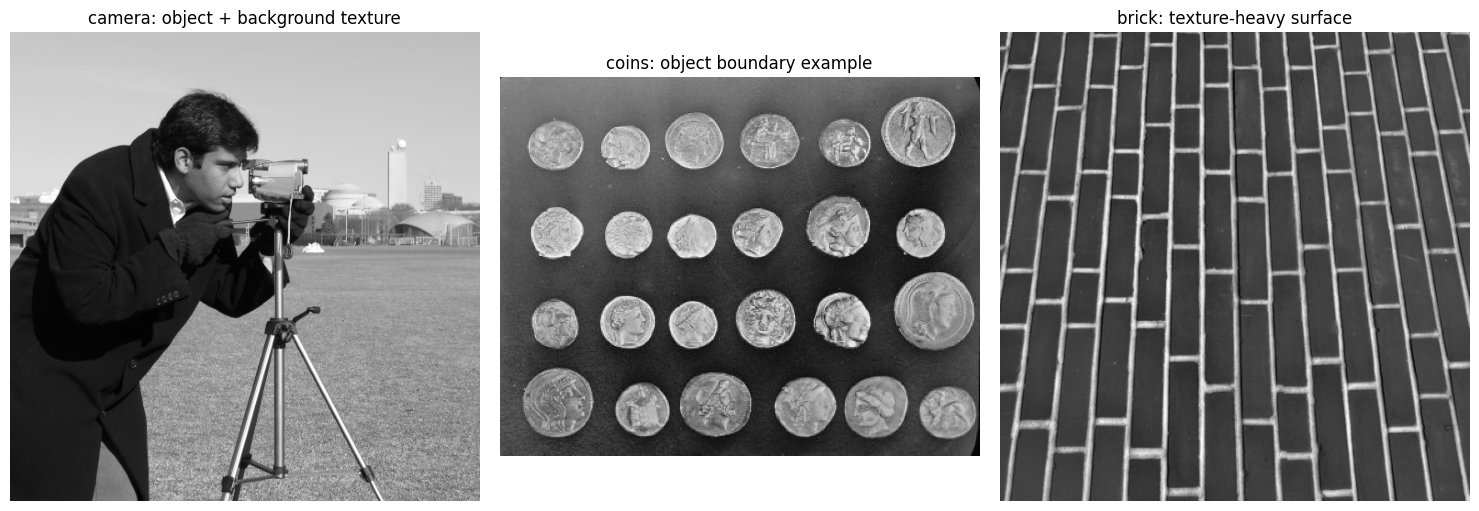

In [38]:
camera = data.camera()
coins = data.coins()
brick = data.brick()

cv2.imwrite(str(OUTPUT_DIR / "01_real_image_camera.png"), camera)
cv2.imwrite(str(OUTPUT_DIR / "02_real_image_coins.png"), coins)
cv2.imwrite(str(OUTPUT_DIR / "03_real_image_brick.png"), brick)

show_images(
    [camera, coins, brick],
    ["camera: object + background texture", "coins: object boundary example", "brick: texture-heavy surface"],
    figsize=(15, 5),
    save_path=OUTPUT_DIR / "00_real_images_used.png"
)


## 2. 一階導數 vs. 二階導數

Derivative plot 的用途，是先用一維 intensity transition 來理解 edge detection。

這張圖不是一張真實影像。  
它是一個 1D intensity profile，用來解釋不同 derivative-based edge detector 會對什麼變化產生反應。

### 一階導數

一階導數量測的是 **intensity 變化得多快**。

比較內化的說法是：

> 一階導數會對「影像正在往上爬或往下掉」的位置產生反應。

如果 intensity 從暗變亮，一階導數會在轉換區域變大。

Sobel 與 Scharr 的基礎就是一階導數。

### 二階導數

二階導數量測的是 **變化速度本身又如何變化**。

比較內化的說法是：

> 二階導數會對「斜率開始改變或停止改變」的位置產生反應。

對一個漸變的 ramp edge 而言，一階導數會在整段斜坡上維持較高；但二階導數會在斜坡開始與結束的位置產生反應。

這也是 Laplacian 容易對細節、雜訊、紋理敏感的原因。

### 如何閱讀 derivative figure

Derivative 曲線有做 scaling 和 offset，目的只是讓它們可以和原始 intensity profile 放在同一張圖裡比較。

真正要看的重點是：

- 一階導數會在 intensity 變化的位置變大
- 二階導數會在斜率開始改變或停止改變的位置產生反應
- 對 gradual ramp transition 而言，二階導數自然會在斜率改變處產生正負反應

下面把 ideal step edge 和 blurred/ramp edge 分開，會比較容易比較兩者行為。


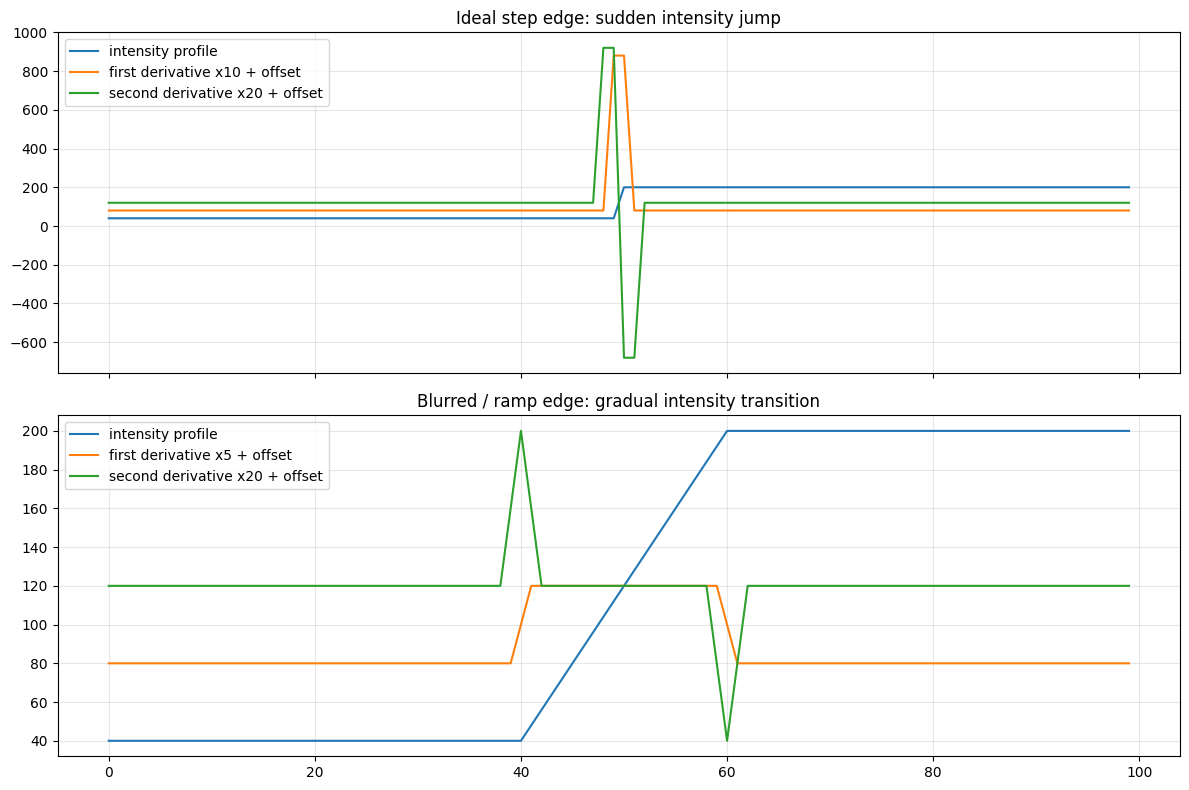

In [39]:
x = np.arange(0, 100)

step = np.where(x < 50, 40, 200).astype(np.float32)
step_first = np.gradient(step)
step_second = np.gradient(step_first)

ramp = np.full_like(x, 40, dtype=np.float32)
ramp[(x >= 40) & (x <= 60)] = np.linspace(40, 200, np.sum((x >= 40) & (x <= 60)))
ramp[x > 60] = 200
ramp_first = np.gradient(ramp)
ramp_second = np.gradient(ramp_first)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(x, step, label="intensity profile")
axes[0].plot(x, step_first * 10 + 80, label="first derivative x10 + offset")
axes[0].plot(x, step_second * 20 + 120, label="second derivative x20 + offset")
axes[0].set_title("Ideal step edge: sudden intensity jump")
axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.3)

axes[1].plot(x, ramp, label="intensity profile")
axes[1].plot(x, ramp_first * 5 + 80, label="first derivative x5 + offset")
axes[1].plot(x, ramp_second * 20 + 120, label="second derivative x20 + offset")
axes[1].set_title("Blurred / ramp edge: gradual intensity transition")
axes[1].legend(loc="upper left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_derivative_explanation_step_vs_ramp.png", dpi=150, bbox_inches="tight")
plt.show()


### 工程意義

Sobel、Scharr 這類一階方法，適合用來找明顯亮度轉換形成的邊界。

Laplacian 這類二階方法，會更強烈地反應 gradient 的局部變化。  
這對細節轉折有用，但也更容易被雜訊與紋理干擾。

所以差異不只是數學定義不同。

它會影響輸出結果：

- 一階方法通常會在 transition 附近產生較寬的 edge-strength band
- 二階方法更容易強調尖銳局部變化，因此結果可能更 speckled
- noisy 或 texture-heavy 區域在二階偵測下通常會變得很活躍


## 3. Kernel Design 與 Edge Detector 行為

對 **convolution-based edge detector** 而言，差異核心通常就在 kernel：

- kernel 的方向決定它對水平、垂直或全方向變化有反應
- kernel 裡的數值決定局部差分怎麼算
- kernel 大小影響雜訊敏感度與細節保留
- 一階 kernel 偵測 slope / gradient
- 二階 kernel 偵測 slope 的變化

所以對 Sobel、Scharr、Laplacian 來說，kernel design 是核心。

但這不是全部。

Canny 不是單純換一個 kernel。  
Canny 是多階段流程：

```text
Gaussian smoothing
→ gradient calculation
→ non-maximum suppression
→ double thresholding
→ edge tracking by hysteresis
```

實務上的結論是：

> 對 Sobel、Scharr、Laplacian 而言，kernel design 是核心差異。  
> 但 Canny 不只是 kernel，它還包含細線化、雙閾值與 edge linking 的流程邏輯。


## 4. Sobel：差分 + 平滑

只說 Sobel 是 edge detector 太表面。

更好的理解是：

> Sobel 使用小型局部 kernel 去計算方向性 intensity change，同時在垂直於差分的方向做一點平滑。

Sobel X kernel：

```text
[-1  0  1]
[-2  0  2]
[-1  0  1]
```

Sobel Y kernel：

```text
[-1 -2 -1]
[ 0  0  0]
[ 1  2  1]
```

核心概念是：

- `[-1, 0, 1]` 在量測左右或上下的差異
- `[1, 2, 1]` 讓中間 row 或 column 權重更高，形成輕微平滑

所以 Sobel 不是單純問：

> 右邊是不是比左邊亮？

它是在整合鄰近 row / column 後再問這件事，因此比單純兩個 pixel 相減更穩定。

### Sobel 擅長什麼？

Sobel 擅長觀察方向性梯度：

- Sobel X 會強調 vertical boundaries，因為那是 left-right intensity change
- Sobel Y 會強調 horizontal boundaries，因為那是 top-bottom intensity change

下面的結果是為了展示這個方向性，而不是只把 Sobel 當作一般 edge map。


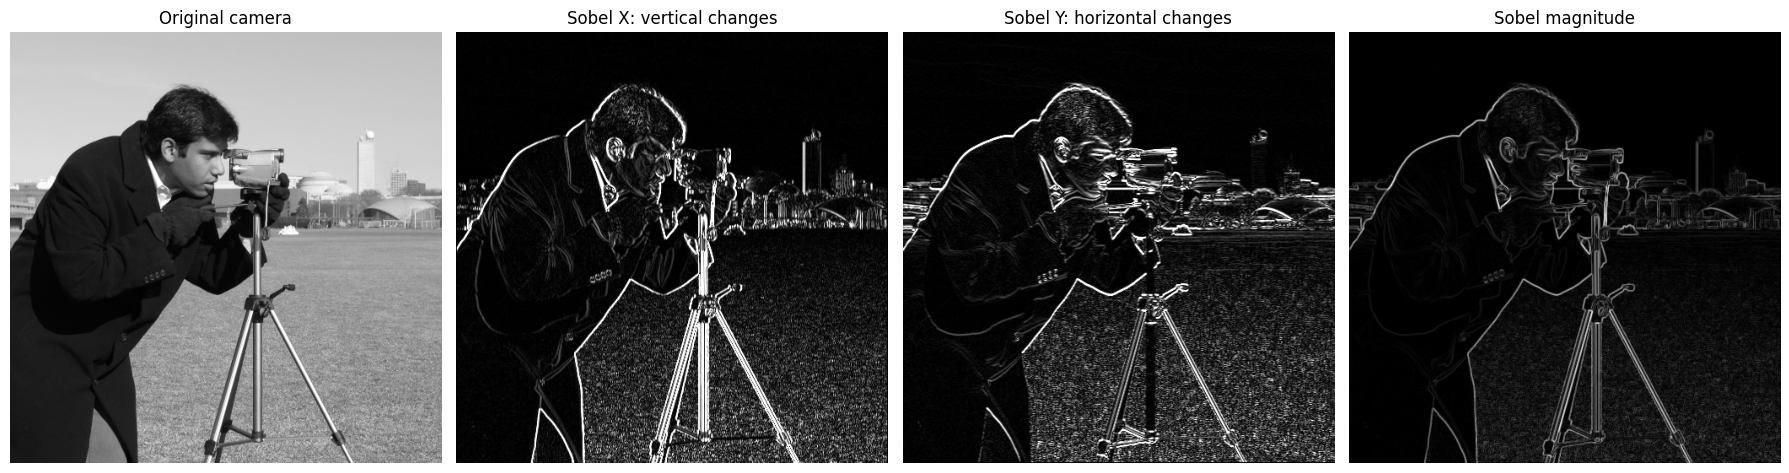

In [40]:
sobel_x_cv = cv2.Sobel(camera, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_cv = cv2.Sobel(camera, cv2.CV_64F, 0, 1, ksize=3)

sobel_x_u8 = cv2.convertScaleAbs(sobel_x_cv)
sobel_y_u8 = cv2.convertScaleAbs(sobel_y_cv)
sobel_mag = np.sqrt(sobel_x_cv**2 + sobel_y_cv**2)
sobel_mag_u8 = to_u8(sobel_mag)

cv2.imwrite(str(OUTPUT_DIR / "05_sobel_x_camera.png"), sobel_x_u8)
cv2.imwrite(str(OUTPUT_DIR / "06_sobel_y_camera.png"), sobel_y_u8)
cv2.imwrite(str(OUTPUT_DIR / "07_sobel_magnitude_camera.png"), sobel_mag_u8)

show_images(
    [camera, sobel_x_u8, sobel_y_u8, sobel_mag_u8],
    ["Original camera", "Sobel X: vertical changes", "Sobel Y: horizontal changes", "Sobel magnitude"],
    figsize=(18, 5),
    save_path=OUTPUT_DIR / "05_sobel_directional_camera.png"
)


### 根據結果的觀察

在 `camera` 影像中：

- Sobel X 對 left-right 變化反應較強，例如相機機身、人物輪廓、腳架的垂直結構。
- Sobel Y 對 top-bottom 變化反應較強，例如相機上的水平邊界與衣服皺摺。
- Magnitude image 則把兩個方向合併起來。

但 Sobel 也會對草地與背景紋理有反應。

這支持一個真正的工程限制：

> Sobel 偵測的是局部亮度變化。  
> 它不知道那個變化是物件邊界、草地紋理、衣服細節，還是雜訊。

因此 Sobel 適合做 gradient analysis，但通常不適合作為最終檢測結果。


## 5. Scharr vs. Sobel：差異存在，但常常很細微

在完整影像上，Sobel 和 Scharr 很可能看起來幾乎一樣。  
這是合理的，因為兩者本質上都是一階 gradient operator。

Scharr 不是神奇版 Sobel。  
它是設計得更好的 3x3 derivative kernel。

### Sobel X

```text
[-1  0  1]
[-2  0  2]
[-1  0  1]
```

### Scharr X

```text
[-3   0   3]
[-10  0  10]
[-3   0   3]
```

### 內化理解

Sobel 和 Scharr 都在問類似的問題：

> 這個小區塊的一側是不是比另一側亮？

差別在於它們怎麼給鄰近 pixels 權重。

Scharr 對中心 row / column 給了更高權重。  
這使得 3x3 小 kernel 在估計 derivative 時通常有更好的近似，尤其在不是完美水平或垂直的邊緣上。

但因為兩者本質上都是一階 gradient 方法，所以結果結構會非常像。

因此比較誠實的結論是：

> Scharr 通常改變的是 gradient response 的強度與平衡，而不是讓 edge map 變成完全不同的東西。

這也是為什麼需要 difference map。  
只看完整結果圖，通常很難用肉眼看出差異。


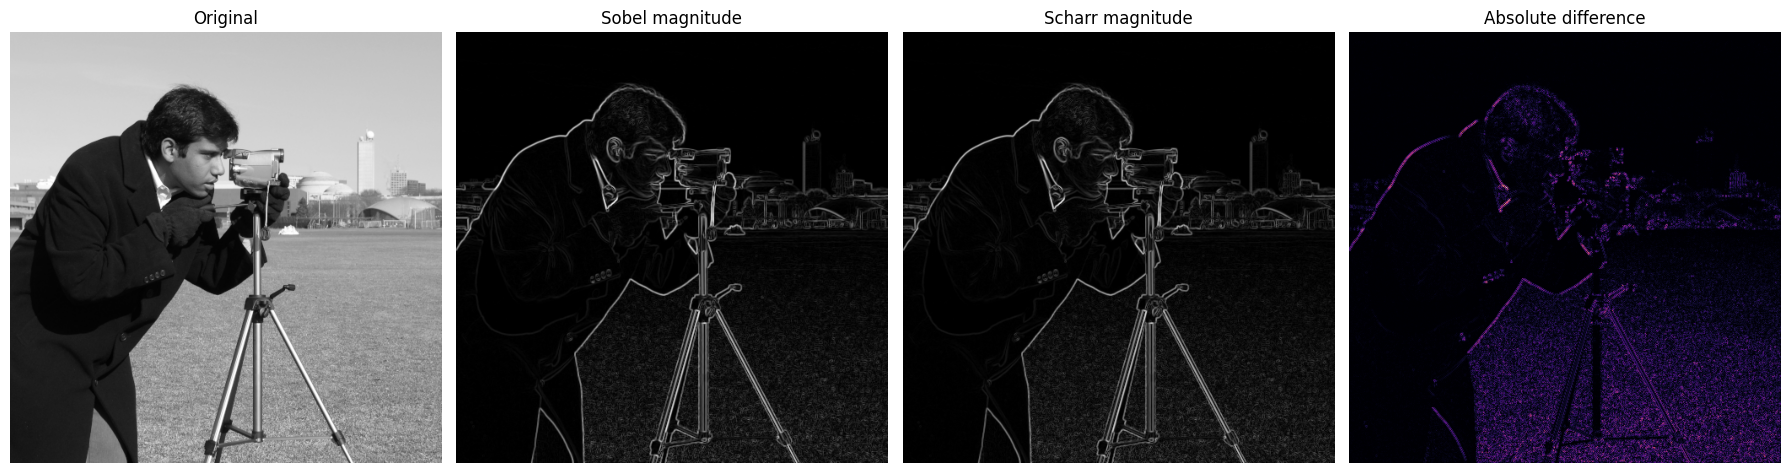

Sobel vs. Scharr absolute difference statistics
Mean difference: 0.002298
Max difference:  0.056027
90th percentile: 0.007112
95th percentile: 0.010558
99th percentile: 0.018165


In [41]:
cam_f = img_as_float(camera)

sobel_sk = filters.sobel(cam_f)
scharr_sk = filters.scharr(cam_f)
diff_sk = np.abs(scharr_sk - sobel_sk)

sobel_vis = to_u8(sobel_sk)
scharr_vis = to_u8(scharr_sk)
diff_vis = to_u8(diff_sk)

cv2.imwrite(str(OUTPUT_DIR / "08_sobel_skimage_camera.png"), sobel_vis)
cv2.imwrite(str(OUTPUT_DIR / "09_scharr_skimage_camera.png"), scharr_vis)
cv2.imwrite(str(OUTPUT_DIR / "10_sobel_scharr_abs_difference.png"), diff_vis)

show_images(
    [camera, sobel_vis, scharr_vis, diff_vis],
    ["Original", "Sobel magnitude", "Scharr magnitude", "Absolute difference"],
    figsize=(18, 5),
    cmaps=["gray", "gray", "gray", "magma"],
    save_path=OUTPUT_DIR / "07_sobel_vs_scharr_with_difference.png"
)

print("Sobel vs. Scharr absolute difference statistics")
print(f"Mean difference: {diff_sk.mean():.6f}")
print(f"Max difference:  {diff_sk.max():.6f}")
print(f"90th percentile: {np.percentile(diff_sk, 90):.6f}")
print(f"95th percentile: {np.percentile(diff_sk, 95):.6f}")
print(f"99th percentile: {np.percentile(diff_sk, 99):.6f}")


### 根據結果的觀察

完整圖上，Sobel 和 Scharr 的結果確實非常相似。

這裡的正確觀察是：**差異很細微**。

Difference map 顯示差異主要集中在強局部結構附近，而不是整張圖都大幅不同。

所以正確的工程結論是：

> 選 Scharr 不是因為它會產生完全不同的 edge map。  
> 而是在需要小型 kernel 且希望 gradient approximation 稍微更好時，它可能更合適。

只看完整圖時，不應該直接說「Scharr 明顯更好」，因為視覺證據通常不夠強。

比較穩健的說法是：

- Sobel 和 Scharr 都是一階 gradient method。
- Scharr 透過 kernel 權重設計改善 3x3 derivative approximation。
- 實際差異可能很細微，需要用 difference map、crop 或 downstream metric 觀察。


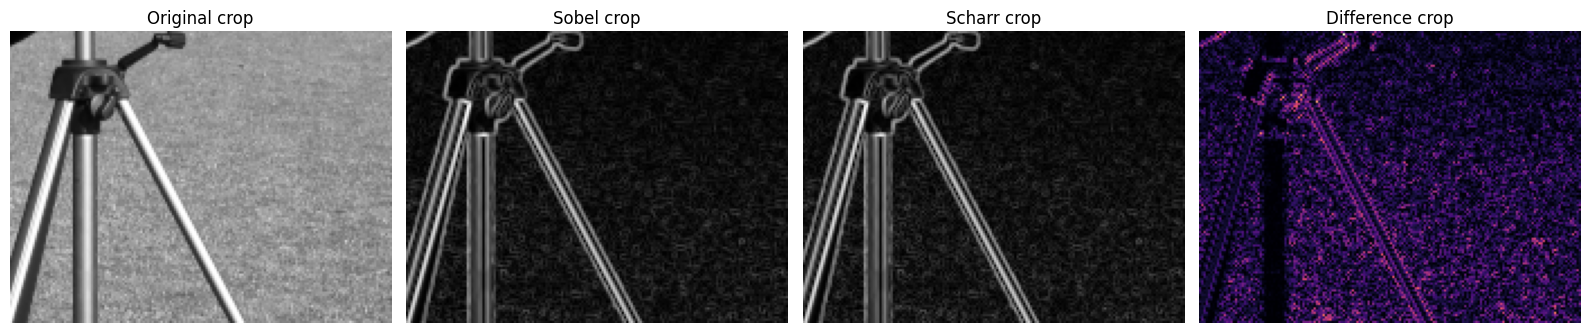

In [42]:
orig_crop = crop(camera, 300, 430, 260, 430)
sob_crop = crop(sobel_sk, 300, 430, 260, 430)
sch_crop = crop(scharr_sk, 300, 430, 260, 430)
diff_crop = crop(diff_sk, 300, 430, 260, 430)

show_images(
    [orig_crop, to_u8(sob_crop), to_u8(sch_crop), to_u8(diff_crop)],
    ["Original crop", "Sobel crop", "Scharr crop", "Difference crop"],
    figsize=(16, 5),
    cmaps=["gray", "gray", "gray", "magma"],
    save_path=OUTPUT_DIR / "08_sobel_vs_scharr_crop_difference.png"
)


## 6. Laplacian：二階變化與為什麼容易 Noisy

Laplacian 使用的是二階導數。

常見 3x3 Laplacian kernel 可能長這樣：

```text
[ 0  1  0]
[ 1 -4  1]
[ 0  1  0]
```

或這樣：

```text
[ 1  1  1]
[ 1 -8  1]
[ 1  1  1]
```

內化理解是：

> 拿中心 pixel 和周圍 pixels 比較。  
> 如果中心和周圍差很多，response 就會變大。

所以 Laplacian 會捕捉各方向的快速局部變化。

但這也直接解釋它的缺點：

> 雜訊也是快速局部變化。  
> 紋理也是大量快速局部變化。

因此 Laplacian 如果沒有先 smoothing，結果通常會很 speckled。

下面結果就是為了直接展示這點。


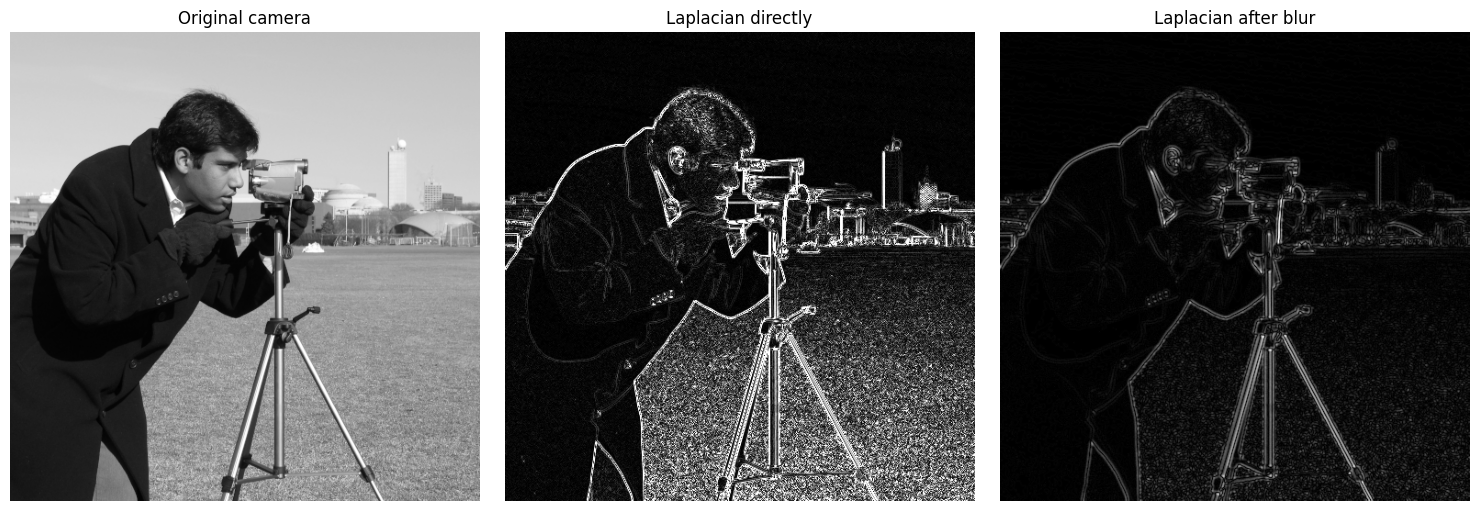

In [43]:
lap_camera = cv2.convertScaleAbs(cv2.Laplacian(camera, cv2.CV_64F, ksize=3))
blur_camera = cv2.GaussianBlur(camera, (5, 5), 0)
lap_blur_camera = cv2.convertScaleAbs(cv2.Laplacian(blur_camera, cv2.CV_64F, ksize=3))

cv2.imwrite(str(OUTPUT_DIR / "10_laplacian_camera_raw.png"), lap_camera)
cv2.imwrite(str(OUTPUT_DIR / "11_laplacian_camera_after_blur.png"), lap_blur_camera)

show_images(
    [camera, lap_camera, lap_blur_camera],
    ["Original camera", "Laplacian directly", "Laplacian after blur"],
    figsize=(15, 5),
    save_path=OUTPUT_DIR / "10_laplacian_raw_vs_blur_camera.png"
)


### 根據結果的觀察

直接使用 Laplacian 時，細節區域會出現很多小反應。

Gaussian blur 後，許多細碎反應被壓掉。

這支撐一個原則：

> Laplacian 對 sharp local change 有用，但在雜訊或紋理強的影像中要小心使用。

這也是為什麼如果目標是取得乾淨的 boundary map 來做 contour extraction，Laplacian 通常不如 Canny 直覺好用。


## 7. Texture Warning：Edge Detection 不理解物件

這一節使用 `brick` 影像。

重點不是做 object detection。  
重點是展示 edge detection 的限制。

磚牆有很多真實 intensity changes，但那些變化大多是 texture，不是你想要抽出的物件邊界。

這張圖可以證明一個重要限制：

> Edge detection 偵測的是視覺變化，不是語意上的物件。

如果表面本身有強烈重複紋理，edge detector 會產生大量 edges，即使沒有明確物件邊界要抽取。


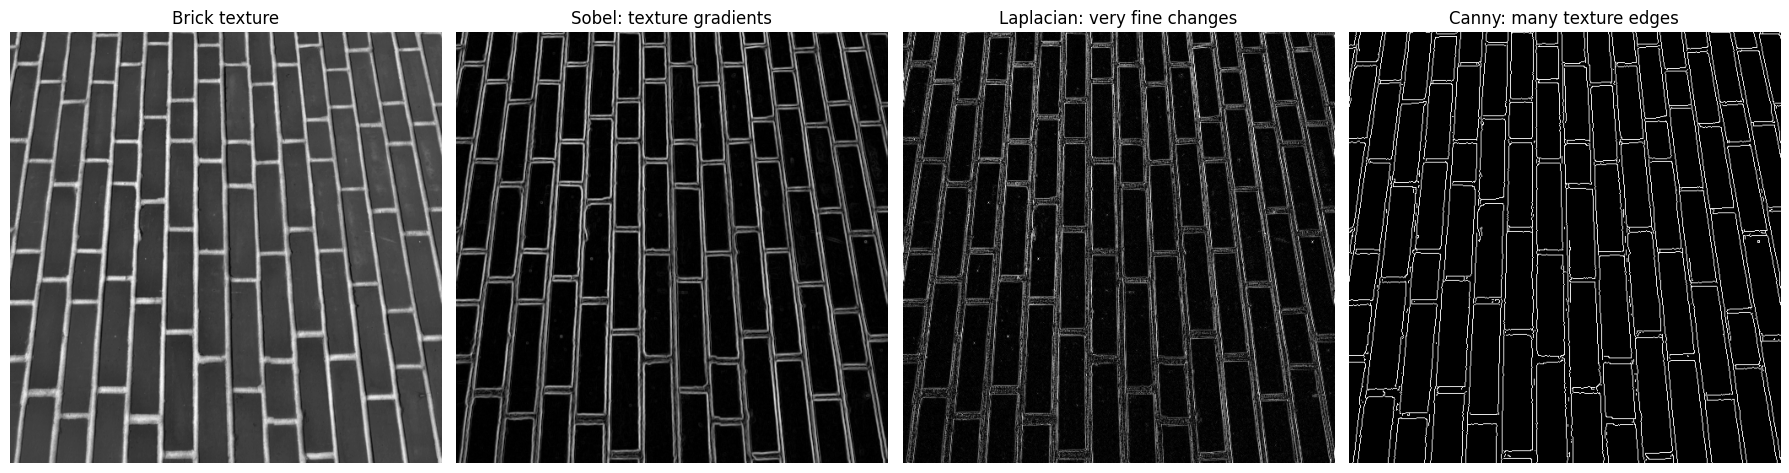

In [44]:
brick_f = img_as_float(brick)
brick_sobel = filters.sobel(brick_f)
brick_lap = cv2.convertScaleAbs(cv2.Laplacian(brick, cv2.CV_64F, ksize=3))
brick_canny = cv2.Canny(brick, 50, 150)

cv2.imwrite(str(OUTPUT_DIR / "12_brick_sobel.png"), to_u8(brick_sobel))
cv2.imwrite(str(OUTPUT_DIR / "13_brick_laplacian.png"), brick_lap)
cv2.imwrite(str(OUTPUT_DIR / "14_brick_canny.png"), brick_canny)

show_images(
    [brick, to_u8(brick_sobel), brick_lap, brick_canny],
    ["Brick texture", "Sobel: texture gradients", "Laplacian: very fine changes", "Canny: many texture edges"],
    figsize=(18, 5),
    save_path=OUTPUT_DIR / "11_texture_warning_brick.png"
)


### 根據結果的觀察

三種方法都對 brick pattern 有很強反應。

這個結果重要，因為它避免錯誤解讀：

> edge 越多，不代表理解越好。

對 AOI 或檢測任務而言，這代表 edge detection 最適合用在目標邊界和背景紋理可以被視覺上區分的情境。

如果表面紋理很強，可能需要：

- controlled lighting
- smoothing
- threshold tuning
- region-based methods
- morphology
- contour filtering
- 或 learning-based method


## 8. Canny：真正擅長的方向在哪裡

這裡不是把 Canny 當成另一張 edge image 來比較。

Canny 的長處更具體：

> Canny 適合產生 thin binary edge map，讓後續可以做 contour extraction。

所以 `coins` 影像比 `camera` 更適合展示 Canny。

Coins 有比較明確的物件邊界，可以觀察 threshold 設定如何影響邊界是否完整。


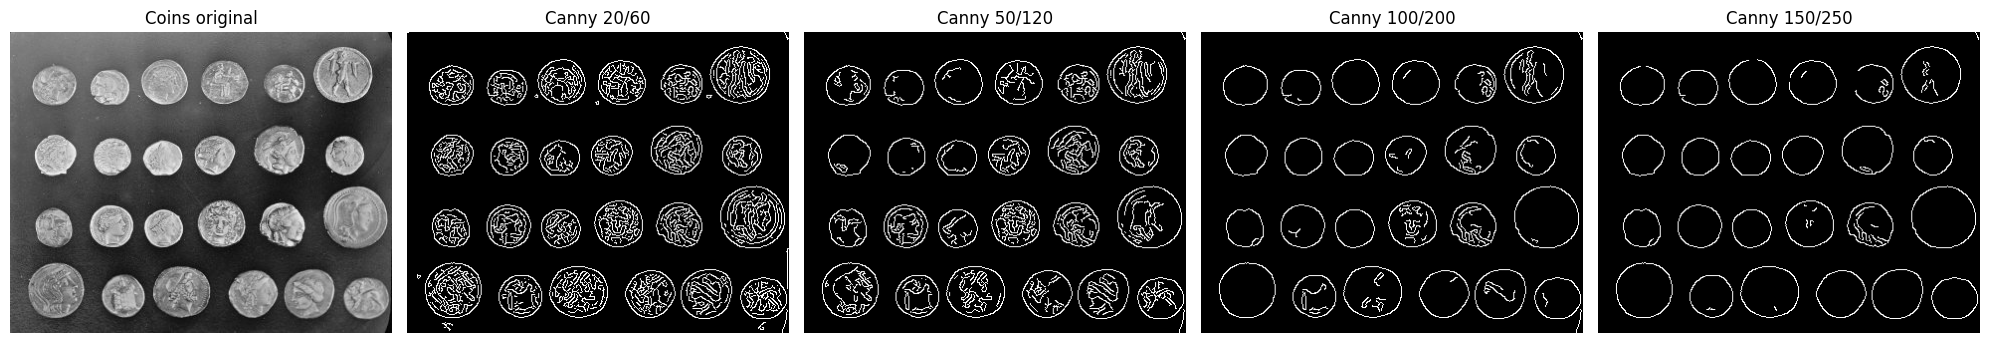

In [45]:
coins_blur = cv2.GaussianBlur(coins, (5, 5), 0)

canny_settings = [(20, 60), (50, 120), (100, 200), (150, 250)]
canny_imgs = []
canny_titles = []

for low, high in canny_settings:
    e = cv2.Canny(coins_blur, low, high)
    canny_imgs.append(e)
    canny_titles.append(f"Canny {low}/{high}")
    cv2.imwrite(str(OUTPUT_DIR / f"15_coins_canny_{low}_{high}.png"), e)

show_images(
    [coins] + canny_imgs,
    ["Coins original"] + canny_titles,
    figsize=(20, 5),
    save_path=OUTPUT_DIR / "12_coins_canny_threshold_comparison.png"
)


### 根據結果的觀察

這個輸出比較能展示 Canny 真正的工程問題。

低 thresholds 會保留更多 coin 細節與內部紋理，但也會產生更多額外 edges。

高 thresholds 會移除內部紋理，但一些較弱的 coin boundaries 可能會變得不完整。

真正的取捨是：

> Canny 擅長產生 thin edge map，但結果是否有用，高度依賴 threshold tuning 與影像條件。

這一節使用適合的影像來支撐結論：目標是 coin boundaries，而輸出能看出那些 boundaries 是否還能被使用。


## 9. Edge Map 到 Contour Extraction

Edge detection 通常不是最終步驟。

對量測或檢測而言，下一步常常是 contour extraction。

這也是 Canny 的 thin binary edge map 有價值的地方。

流程是：

```text
blur
→ Canny
→ find contours
→ filter by area / perimeter / shape
→ measure or inspect
```


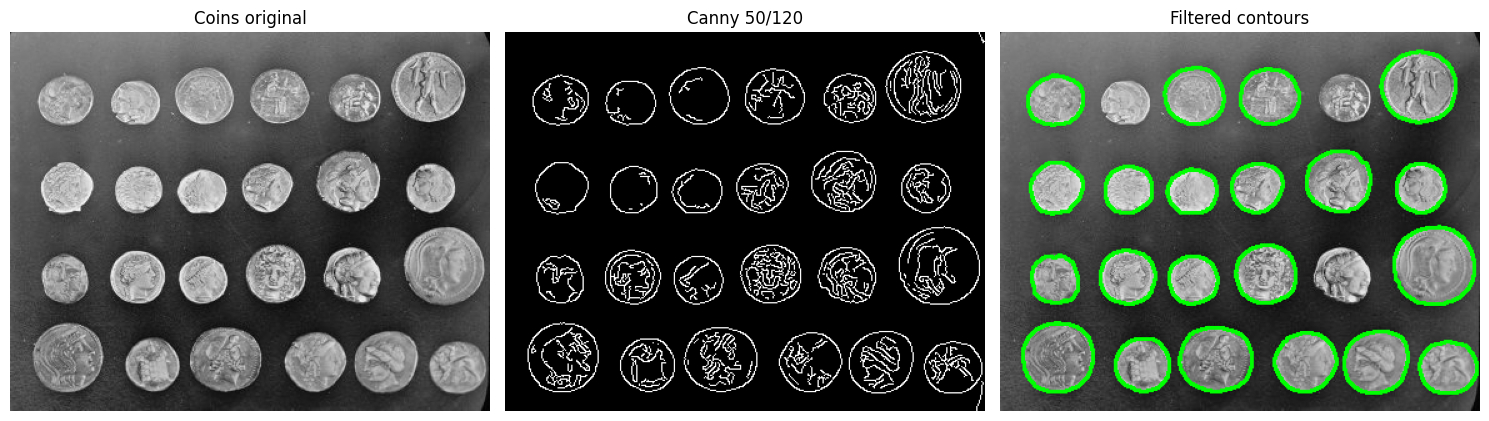

Raw contours: 44
Filtered contours: 21


In [46]:
coins_edge = cv2.Canny(coins_blur, 50, 120)

contours, _ = cv2.findContours(coins_edge, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
coins_bgr = cv2.cvtColor(coins, cv2.COLOR_GRAY2BGR)

filtered = []
for c in contours:
    area = cv2.contourArea(c)
    perimeter = cv2.arcLength(c, True)
    if area > 80 and perimeter > 40:
        filtered.append(c)

cv2.drawContours(coins_bgr, filtered, -1, (0, 255, 0), 2)
cv2.imwrite(str(OUTPUT_DIR / "16_coins_contours_from_canny.png"), coins_bgr)

show_images(
    [coins, coins_edge, coins_bgr],
    ["Coins original", "Canny 50/120", "Filtered contours"],
    figsize=(15, 5),
    save_path=OUTPUT_DIR / "13_coins_edge_to_contours.png"
)

print(f"Raw contours: {len(contours)}")
print(f"Filtered contours: {len(filtered)}")


### 根據結果的觀察

這個結果比單純拿 Canny 和 Sobel 比較更能展示 Canny 的長處。

Canny 產生的 binary edge map 可以接到 `findContours`。

但 contour 仍然不是完美的。  
有些邊界可能斷裂，有些 coin 內部細節也可能造成不想要的 contours。

所以工程結論是：

> Canny 有用，是因為它可以把 edge pixels 準備成適合 contour-based processing 的形式。  
> 但它本身不是 object detection 的完整解法。


## 10. 最終方法選擇總結

| Method | 核心機制 | 最適合展示的結果 | 真正長處 | 主要限制 |
|---|---|---|---|---|
| Sobel | 一階方向性 kernel | camera 影像上的 Sobel X / Y | 顯示水平與垂直 intensity change | 會對紋理與雜訊反應 |
| Scharr | 改良版 3x3 一階 kernel | 和 Sobel 的 difference map | 小 kernel 下有稍好的 gradient behavior | 差異可能很細微 |
| Laplacian | 二階全方向 kernel | raw vs. blurred Laplacian | 偵測快速局部變化 | 對雜訊與紋理非常敏感 |
| Canny | 完整 edge pipeline | coins threshold + contours | 適合產生 thin binary edge map 並接 contour extraction | 依賴 threshold tuning 與穩定影像條件 |

核心實務結論是：

> 不要只因為結果圖看起來銳利就選某個 edge detector。  
> 要根據它量測哪一種局部變化，以及這個輸出是否幫助下一步處理來選。

對傳統 CV / AOI 流程而言，edge detection 通常只是其中一個階段：

```text
preprocessing
→ edge detection
→ thresholding or morphology
→ contour extraction
→ geometric filtering
→ measurement / OK-NG decision
```
